In [ ]:
from BoardDetection import BoardDetection
from PieceDetection.PieceCropper_3D import PieceCropper
from Dataset.DataSetLoaders.ChessDataset import ChessDataset

import os
import sys

import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from torch.nn import functional as F

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.utils.class_weight import compute_class_weight

from torchvision import transforms
from torchvision import models
import numpy as np
from matplotlib import pyplot as plt
from PIL import Image

import math
import pickle
from tqdm.auto import tqdm

/mnt/D/University/Thesis/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [ ]:
def preprocess_fn(padding=(0,0)):
    def main(content):
        img, label = content
        
        BoardDetection.board_extractor.set_img(img)
        quad, conf = BoardDetection.board_extractor.extract_board()
        # warpped, M = BE.warp(quad, padding=padding)

        # orig_size = label["original_img_size"]
        orig_size = None

        PieceCropper.piece_cropper.set_img(img, torch.tensor(quad))
        board_split = PieceCropper.piece_cropper.process_img(original_img_size=orig_size)

        return board_split, label

    return main

def post_transform(img):
    return torch.tensor(img).permute(2,0,1)

In [4]:
count_ds = ChessDataset(
    root_dirs="/mnt/D/University/Thesis_Dataset/Cropped_Dataset/",
    config={
        "img_size": (320,320)
    },
    force_build_pkl=True
)

occupancy_count = 0
occupied_count = 0
white_count = 0
piece_counts = {
    "P": 0,
    "N": 0,
    "B": 0,
    "R": 0,
    "Q": 0,
    "K": 0
}
piece_types = ['P', 'N', 'B', 'R', 'Q', 'K']
for img, y in count_ds:
    board: torch.Tensor = y["board_tensor"]
    occupancy_count += 64
    occupied_count += (board != 12).sum().item()
    white_count += (board < 6).sum().item()
    for i, piece_type in enumerate(piece_types):
        piece_counts[piece_type] += ((board == i) | (board == i+6)).sum().item()

occupancy_count, occupied_count, white_count, piece_counts

(23424,
 6492,
 3241,
 {'P': 3399, 'N': 461, 'B': 530, 'R': 924, 'Q': 448, 'K': 730})

('/mnt/D/University/Thesis_Dataset/Cropped_Dataset/Images/image_280.jpg',
 torch.Size([3, 320, 320]))

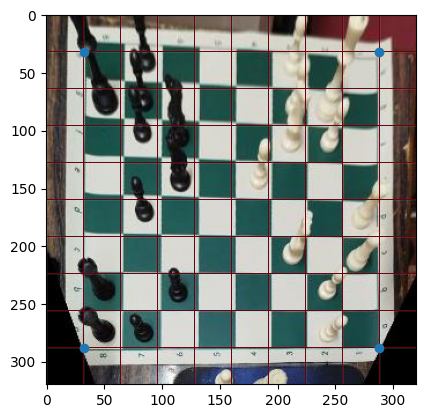

In [5]:
img, label = count_ds[278]
grid = np.zeros(img.shape[1:], dtype=np.float32)
plt.imshow(img.permute(1,2,0));
plt.scatter(np.array([32, 288, 288,32]), np.array([32, 32, 288, 288]));
grid[::32, :] = 1
grid[:, ::32] = 1
plt.imshow(grid, alpha=grid, cmap="Reds")
label["image_path"], img.shape

In [6]:
ds = ChessDataset(
    config={
        "img_size": (640,640),
    },
    img_label_transforms = transforms.Compose([
            preprocess_fn(),
        ]),
    force_build_pkl=True
)

train_ds, valid_ds, test_ds = ChessDataset.train_valid_test_split(ds, sizes=(.8,.1,.1), random_state=42)

# train_ds, test_ds = train_test_split(ds, test_size=0.1, random_state=42)

train_dl = ChessDataset.getLoader(train_ds, 16, 0)
valid_dl = ChessDataset.getLoader(valid_ds, 16, 0)
test_dl = ChessDataset.getLoader(test_ds, 16, 0)

torch.Size([8, 8, 3, 64, 64])


'/mnt/D/University/Thesis_Dataset/Dataset/Images/image_280.jpg'

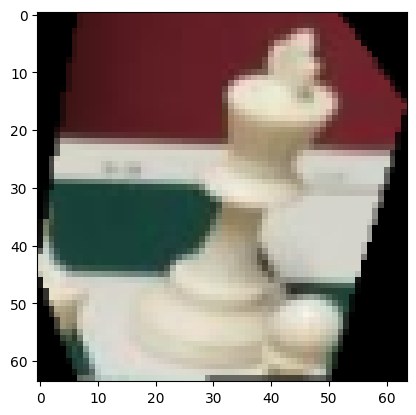

In [7]:
# board_split, y = ds[100]
board_split, y = ds[5]

# grid = np.zeros((warpped.shape[1], warpped.shape[2]))
# step = 32
# # Set pixels in rows and columns that are multiples of step to 1
# grid[::step, :] = 1   # horizontal lines
# grid[:, ::step] = 1   # vertical lines

# plt.imshow(warpped.permute(1,2,0));
# plt.imshow(grid, alpha=grid, cmap='Reds');

print(board_split.shape)
plt.imshow(board_split[1,6].permute(1,2,0));
y["image_path"]

In [8]:
class PieceDetectorCNNModel(nn.Module):
    def __init__(self):
        super().__init__()

        self.latent_dim = 512

        self.resnet = models.resnet18(pretrained=True)
        for param in self.resnet.parameters():
            param.requires_grad = False
        self.resnet = nn.Sequential(*list(self.resnet.children())[:-1])  # Remove the last FC layer and avgpool
        for param in self.resnet[-2:].parameters():
            param.requires_grad = True

        dropporb = .2

        # self.conv1 = nn.Sequential(
        #     # 32, 32
        #     nn.Conv2d(3, 16, 3, padding=1),
        #     nn.LeakyReLU(),
        #     nn.BatchNorm2d(16),
        #     nn.MaxPool2d(4),
        #     nn.Dropout(dropporb),

        #     # 8, 8
        #     nn.Conv2d(16, 64, 3, padding=1),
        #     nn.LeakyReLU(),
        #     nn.BatchNorm2d(64),
        #     nn.MaxPool2d(4),
        #     nn.Dropout(dropporb),

        #     # 2,2
        #     nn.Conv2d(64, 128, 3, padding=1),
        #     nn.LeakyReLU(),
        #     nn.BatchNorm2d(128),
        #     nn.MaxPool2d(2),
        #     nn.Dropout(dropporb),

        #     # 1, 1
        # )

        self.conv1 = nn.Sequential(
            nn.Flatten(),
            nn.Linear(512, self.latent_dim),
            nn.LeakyReLU(),

            # nn.AdaptiveAvgPool2d((1,1))
        )

        self.conv2 = nn.Sequential(
            nn.Conv2d(self.latent_dim, self.latent_dim, 3, padding=1),
            nn.LeakyReLU(),
            # nn.BatchNorm2d(self.latent_dim),
            # nn.AdaptiveAvgPool2d((8,8)),
            nn.Dropout(dropporb),

            nn.Conv2d(self.latent_dim, self.latent_dim, 3, padding=1),
            nn.LeakyReLU(),
            # nn.BatchNorm2d(self.latent_dim),
            # nn.AdaptiveAvgPool2d((8,8)),
            nn.Dropout(dropporb),

            nn.AdaptiveAvgPool2d((8,8))
        )

        self.classifier = nn.Sequential(
            # nn.Linear(128, 64),
            # nn.LeakyReLU(),
            # nn.Dropout(dropporb),
        )

        self.occupancy_classifier_heads = nn.Sequential(
            nn.Linear(self.latent_dim, 128),
            nn.LeakyReLU(),
            nn.Dropout(dropporb),
            nn.Linear(128, 1)
        )
        self.piece_color_classifier_heads = nn.Sequential(
            nn.Linear(self.latent_dim, 128),
            nn.LeakyReLU(),
            nn.Dropout(dropporb),
            nn.Linear(128, 1)
        )
        self.piece_type_classifier_heads = nn.Sequential(
            nn.Linear(self.latent_dim, 128),
            nn.LeakyReLU(),
            nn.Dropout(dropporb),
            nn.Linear(128, 6)
        )

        self.pos_emb = nn.Parameter(torch.zeros(self.latent_dim, 8, 8))
        self.sin_pos_emb = None  # [C, 8, 8]

    def sinusoidal_embeddings_2d(self, height=10, width=10):
        """
        Create 2D sinusoidal positional embeddings for an (H, W) grid.

        height, width: grid size
        d_model: total embedding dimension (should be even)

        Returns:
            pos_emb: [H, W, d_model] tensor
        """
        d_model = self.latent_dim
        if self.sin_pos_emb is not None and (tuple(self.sin_pos_emb.shape) == (d_model, height, width)):
            return self.sin_pos_emb

        if d_model % 4 != 0:
            raise ValueError("d_model must be divisible by 4 for 2D sin/cos.")

        # Position indices
        y_pos = torch.arange(height, dtype=torch.float32).unsqueeze(1)  # [H, 1]
        x_pos = torch.arange(width, dtype=torch.float32).unsqueeze(1)   # [W, 1]

        # Each axis gets d_model/2 dimensions, split into sin/cos → d_model/4 each
        d_model_half = d_model // 2
        div_term = torch.exp(torch.arange(0, d_model_half, 2).float() * (-math.log(10000.0) / d_model_half))

        # Row (y) embeddings
        pe_y = torch.zeros(height, d_model_half)
        pe_y[:, 0::2] = torch.sin(y_pos * div_term)
        pe_y[:, 1::2] = torch.cos(y_pos * div_term)

        # Col (x) embeddings
        pe_x = torch.zeros(width, d_model_half)
        pe_x[:, 0::2] = torch.sin(x_pos * div_term)
        pe_x[:, 1::2] = torch.cos(x_pos * div_term)

        # Combine row and col into [H, W, d_model]
        pe = torch.zeros(height, width, d_model)
        for i in range(height):
            for j in range(width):
                pe[i, j] = torch.cat([pe_y[i], pe_x[j]], dim=0)

        self.sin_pos_emb = pe.permute(2, 0, 1).to(device)
        return self.sin_pos_emb

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x: B, 8,8,c,32,32
        # x = x.permute(0,3,1,2,4,5)

        sq_size = (x.shape[4],x.shape[5])
        B = x.shape[0]
        C = x.shape[3]
        if C != 3:
            raise Exception("Invalid Image")
        
        # board_split = x.reshape(B, C, 10, sq_size[0], 10, sq_size[1]).permute(0,1,2,4,3,5)
        # board_split = x

        # embeds = self.conv1(board_split.permute(0,2,3,1,4,5).reshape(-1,C,sq_size[0],sq_size[1])).squeeze(-1).squeeze(-1).reshape(B, 10,10, 128).permute(0,3,1,2)
        embeds = self.conv1(self.resnet(x.reshape(-1,C,sq_size[0],sq_size[1]))).squeeze(-1).squeeze(-1).reshape(B, 8,8, self.latent_dim).permute(0,3,1,2)

        sin_pos_emb = self.sinusoidal_embeddings_2d(8,8)

        # positioned_embeds = embeds + self.pos_emb + sin_pos_emb
        # positioned_embeds = embeds + sin_pos_emb
        positioned_embeds = embeds
        # attentioned_embeds = embeds.reshape(B, 10,10, 128).permute(0,3,1,2)
        attentioned_embeds = self.conv2(positioned_embeds)
        # cropped_attentioned_embeds = attentioned_embeds[:,:,1:9,1:9]
        res = self.classifier(attentioned_embeds.permute(0,2,3,1).reshape(-1, self.latent_dim))
        res_occupancy = self.occupancy_classifier_heads(res).reshape(B, 8,8)
        res_piece_color = self.piece_color_classifier_heads(res).reshape(B, 8,8)
        res_piece_type = self.piece_type_classifier_heads(res).reshape(B, 8,8, 6)

        return {
            "occupancy": res_occupancy,
            "piece_color": res_piece_color,
            "piece_type": res_piece_type,
        }

In [9]:
model = PieceDetectorCNNModel().to(device)

/mnt/D/University/Thesis/.venv/lib/python3.13/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/mnt/D/University/Thesis/.venv/lib/python3.13/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [11]:
for x, l in train_dl:
    with torch.inference_mode():
        res = model(x.to(device))
    print(res["occupancy"].shape)
    print(res["piece_color"].shape)
    print(res["piece_type"].shape)
    # print(res.shape)
    # print(l)

    # plt.imshow(x[0].permute(1,2,0));
    break

torch.Size([16, 8, 8])
torch.Size([16, 8, 8])
torch.Size([16, 8, 8, 6])


In [ ]:
def train(model: nn.Module, train_loader, valid_loader, lr=1e-3, epochs=30):
    model.train()
    
    optimzier = torch.optim.Adam(model.parameters(), lr=lr)
    # class_weights = 64/(torch.tensor([8,2,2,2,1,1,8,2,2,2,1,1,32]))
    class_weights = 6492/(6*torch.tensor([3399, 461, 530, 924, 448, 730], device=device))
    loss_fn_binary_occupancy = nn.BCEWithLogitsLoss(weight=torch.tensor((occupancy_count-occupied_count)/occupied_count, device=device))
    loss_fn_binary_color = nn.BCEWithLogitsLoss(weight=torch.tensor((occupied_count-white_count)/white_count, device=device))
    loss_fn_type = nn.CrossEntropyLoss(weight=class_weights)

    relative_weights = (1,3,6)

    def loss_fn(preds: dict[str, torch.Tensor], y: dict[str, torch.Tensor]) -> torch.Tensor:
        loss: torch.Tensor = \
                relative_weights[0] * loss_fn_binary_occupancy(preds["occupancy"], y["occupancy"]) + \
                relative_weights[1] * loss_fn_binary_color(preds["piece_color"]*y["occupancy"], (y["piece_color"])*y["occupancy"]) + \
                relative_weights[2] * loss_fn_type(preds["piece_type"]*y["occupancy"].unsqueeze(1), (y["piece_type"]*y["occupancy"]).to(torch.long))
        
        loss /= sum(relative_weights)

        return loss

    tracked_train_loss = []
    tracked_valid_loss = []

    tracked_train_acc = {
        "occupancy": [],
        "piece_color": [],
        "piece_type": [],
    }

    tracked_valid_acc = {
        "occupancy": [],
        "piece_color": [],
        "piece_type": [],
    }

    best_loss = None
    for epoch in range(epochs):
        model.train()
        train_loss = 0
        train_acc = {
            "occupancy": 0,
            "piece_color": 0,
            "piece_type": 0,
        }
        train_count = 0
        train_occupied_count = 0
        for X, L in tqdm(train_loader):
            y: torch.Tensor = L["board_tensor"]
            X: torch.Tensor = X.to(device)
            y: torch.Tensor = y.to(device)

            preds: torch.Tensor = model(X)
            preds["occupancy"] = preds["occupancy"].reshape(-1)
            preds["piece_color"] = preds["piece_color"].reshape(-1)
            preds["piece_type"] = preds["piece_type"].reshape(-1, 6)

            # y = y.reshape(-1, 13)
            y_occupancy = (y < 12).to(torch.float32).reshape(-1)
            y_piece_color = (y<6).to(torch.float32).reshape(-1)
            y_piece_type = (y%6).to(torch.float32).reshape(-1)
            # y_piece_type = F.one_hot(y_piece_type.to(torch.long), 6)
            y = {
                "occupancy": y_occupancy,
                "piece_color": y_piece_color,
                "piece_type": y_piece_type
            }

            optimzier.zero_grad()
            loss = loss_fn(preds, y)
            loss.backward()
            optimzier.step()

            train_loss += loss.item()
            train_count += X.shape[0]*8*8
            train_occupied_count += y_occupancy.sum().item()

            train_acc["occupancy"] += ((preds["occupancy"].sigmoid() > .5) == y_occupancy).sum().item()
            train_acc["piece_color"] += (((preds["piece_color"].sigmoid() > .5) == y_piece_color).to(torch.int8)*y_occupancy).sum().item()
            train_acc["piece_type"] += ((preds["piece_type"].softmax(dim=1).argmax(dim=1) == y_piece_type).to(torch.int8)*y_occupancy).sum().item()

        train_loss /= train_count
        train_acc["occupancy"] /= train_count
        train_acc["piece_color"] /= train_occupied_count
        train_acc["piece_type"] /= train_occupied_count


        model.eval()
        valid_loss = 0
        valid_acc = {
            "occupancy": 0,
            "piece_color": 0,
            "piece_type": 0,
        }
        valid_count = 0
        valid_occupied_count = 0
        with torch.inference_mode():
            for X, L in tqdm(valid_loader):
                y: torch.Tensor = L["board_tensor"]
                X: torch.Tensor = X.to(device)
                y: torch.Tensor = y.to(device)

                preds: torch.Tensor = model(X)
                preds["occupancy"] = preds["occupancy"].reshape(-1)
                preds["piece_color"] = preds["piece_color"].reshape(-1)
                preds["piece_type"] = preds["piece_type"].reshape(-1, 6)

                # y = y.reshape(-1, 13)
                y_occupancy = (y < 12).to(torch.float32).reshape(-1)
                y_piece_color = (y<6).to(torch.float32).reshape(-1)
                y_piece_type = (y%6).to(torch.float32).reshape(-1)
                # y_piece_type = F.one_hot(y_piece_type.to(torch.long), 6)
                y = {
                    "occupancy": y_occupancy,
                    "piece_color": y_piece_color,
                    "piece_type": y_piece_type
                }

                loss = loss_fn(preds, y)

                valid_loss += loss.item()
                valid_count += X.shape[0]*8*8
                valid_occupied_count += y_occupancy.sum().item()

                valid_acc["occupancy"] += ((preds["occupancy"].sigmoid() > .5) == y_occupancy).sum().item()
                valid_acc["piece_color"] += (((preds["piece_color"].sigmoid() > .5) == y_piece_color).to(torch.int8)*y_occupancy).sum().item()
                valid_acc["piece_type"] += ((preds["piece_type"].softmax(dim=1).argmax(dim=1) == y_piece_type).to(torch.int8)*y_occupancy).sum().item()

            valid_loss /= valid_count
            valid_acc["occupancy"] /= valid_count
            valid_acc["piece_color"] /= valid_occupied_count
            valid_acc["piece_type"] /= valid_occupied_count

        if best_loss is None or valid_loss < best_loss:
            print(f"Valid Loss Improved: {best_loss} -> {valid_loss}")
            best_loss = valid_loss
            torch.save(model.state_dict(), "best_model.pt")

        tracked_train_loss.append(train_loss)
        tracked_valid_loss.append(valid_loss)

        tracked_train_acc["occupancy"].append(train_acc["occupancy"])
        tracked_train_acc["piece_color"].append(train_acc["piece_color"])
        tracked_train_acc["piece_type"].append(train_acc["piece_type"])

        tracked_valid_acc["occupancy"].append(valid_acc["occupancy"])
        tracked_valid_acc["piece_color"].append(valid_acc["piece_color"])
        tracked_valid_acc["piece_type"].append(valid_acc["piece_type"])

        print(f"Epoch {epoch+1}/{epochs} |  Train Loss {train_loss:.4f} | Train Accuracy {train_acc["occupancy"]:.2f} {train_acc["piece_color"]:.2f} {train_acc["piece_type"]:.2f} | Valid Loss {valid_loss:.4f} | Valid Accuracy {valid_acc["occupancy"]:.2f} {valid_acc["piece_color"]:.2f} {valid_acc["piece_type"]:.2f}")
    
    torch.save(model.state_dict(), "last_model.pt")

    plt.figure(figsize=(12,8))
    plt.subplot(1,4,1)
    plt.plot(range(epochs), tracked_train_loss, c="r");
    plt.plot(range(epochs), tracked_valid_loss, c='b');

    plt.subplot(1,4,2)
    plt.plot(range(epochs), tracked_train_acc["occupancy"], c='r');
    plt.plot(range(epochs), tracked_valid_acc["occupancy"], c='b');
    plt.subplot(1,4,3)
    plt.plot(range(epochs), tracked_train_acc["piece_color"], c='r');
    plt.plot(range(epochs), tracked_valid_acc["piece_color"], c='b');
    plt.subplot(1,4,4)
    plt.plot(range(epochs), tracked_train_acc["piece_type"], c='r');
    plt.plot(range(epochs), tracked_valid_acc["piece_type"], c='b');

  0%|          | 0/19 [00:00<?, ?it/s]

100%|██████████| 3/3 [00:05<00:00,  1.87s/it]


Epoch 1/15 |  Train Loss 0.0014 | Train Accuracy 0.69 0.51 0.27 | Valid Loss 0.0020 | Valid Accuracy 0.72 0.61 0.39


100%|██████████| 3/3 [00:05<00:00,  1.97s/it]


Epoch 2/15 |  Train Loss 0.0013 | Train Accuracy 0.78 0.58 0.43 | Valid Loss 0.0017 | Valid Accuracy 0.84 0.67 0.52


...

Epoch 13/15 |  Train Loss 0.0007 | Train Accuracy 0.99 0.99 0.97 | Valid Loss 0.0015 | Valid Accuracy 0.98 0.98 0.82


100%|██████████| 3/3 [00:09<00:00,  3.24s/it]


Epoch 14/15 |  Train Loss 0.0007 | Train Accuracy 0.99 0.99 0.98 | Valid Loss 0.0015 | Valid Accuracy 0.98 0.99 0.80


100%|██████████| 3/3 [00:09<00:00,  3.09s/it]


Epoch 15/15 |  Train Loss 0.0007 | Train Accuracy 0.99 1.00 0.98 | Valid Loss 0.0015 | Valid Accuracy 0.98 0.98 0.82


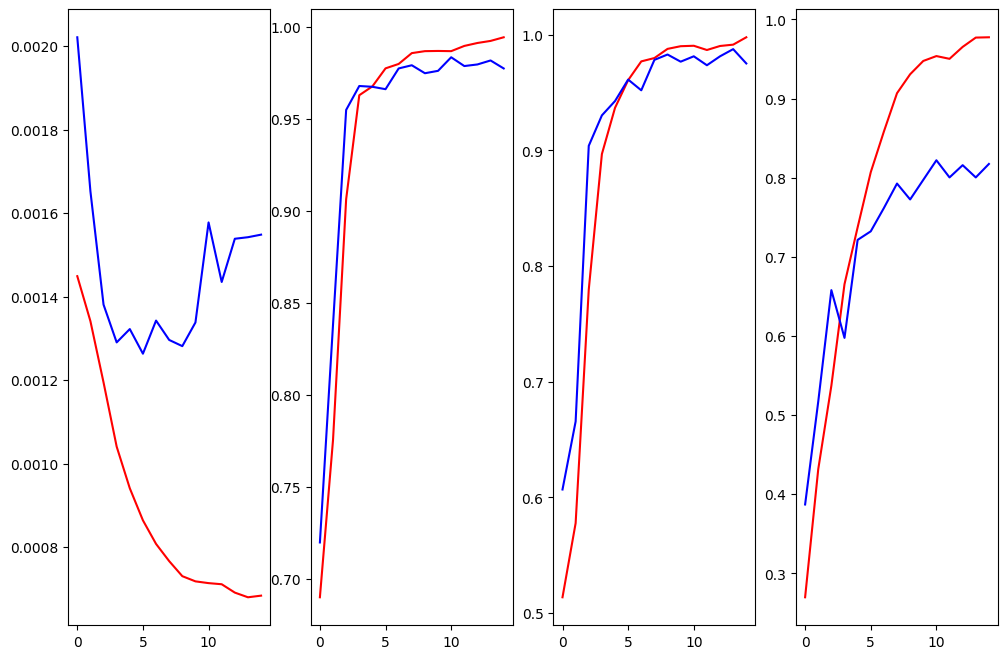

In [13]:
train(model, train_dl, valid_dl, epochs=15)

In [19]:
def test(model: nn.Module, test_loader):
    model.eval()
    
    # class_weights = 64/(torch.tensor([8,2,2,2,1,1,8,2,2,2,1,1,32]))
    # loss_fn = nn.CrossEntropyLoss(weight=class_weights.to(device))
    loss_fn_binary = nn.BCEWithLogitsLoss()
    loss_fn = nn.CrossEntropyLoss()

    combined_preds = {
        "occupancy": [],
        "piece_color": [],
        "piece_type": [],
        "all": []
    }
    combined_y = {
        "occupancy": [],
        "piece_color": [],
        "piece_type": [],
        "all": []
    }

    test_loss = 0
    test_acc = {
        "occupancy": 0,
        "piece_color": 0,
        "piece_type": 0,
        "all": 0
    }
    test_count = 0
    test_occupied_count = 0
    with torch.inference_mode():
        for X, L in tqdm(test_loader):
            y = L["board_tensor"]
            X = X.to(device)
            y = y.to(device)

            B = X.shape[0]

            preds: torch.Tensor = model(X)
            preds["occupancy"] = preds["occupancy"].reshape(-1)
            preds["piece_color"] = preds["piece_color"].reshape(-1)
            preds["piece_type"] = preds["piece_type"].reshape(-1, 6)

            # y = y.reshape(-1, 13)
            y_occupancy = (y < 12).to(torch.float32).reshape(-1)
            y_piece_color = (y<6).to(torch.float32).reshape(-1)
            y_piece_type = (y%6).to(torch.float32).reshape(-1)
            y = y.flatten()
            # y_piece_type = F.one_hot(y_piece_type.to(torch.long), 6)

            loss: torch.Tensor = loss_fn_binary(preds["occupancy"], y_occupancy) + \
                loss_fn_binary(preds["piece_color"]*y_occupancy, (y_piece_color)*y_occupancy) + \
                loss_fn(preds["piece_type"]*y_occupancy.unsqueeze(1), (y_piece_type*y_occupancy).to(torch.long))

            test_loss += loss.item()
            test_count += X.shape[0]*8*8
            test_occupied_count += y_occupancy.sum().item()

            preds["occupancy"] = (preds["occupancy"].sigmoid())
            preds["piece_color"] = (preds["piece_color"].sigmoid())
            preds["piece_type"] = preds["piece_type"].softmax(dim=1)
            

            pred = torch.zeros(B*8*8, 13, device=device)
            pred[:,12] = 1-preds["occupancy"]
            pred[:,:6] = (preds["piece_type"] * preds["piece_color"].unsqueeze(1)) * (preds["occupancy"].unsqueeze(1))
            pred[:,6:12] = (preds["piece_type"] * (1-preds["piece_color"].unsqueeze(1))) * (preds["occupancy"].unsqueeze(1))
            
            preds["occupancy"] = preds["occupancy"] > .5
            preds["piece_color"] = preds["piece_color"] > .5
            preds["piece_type"] = preds["piece_type"].argmax(dim=1)
            pred = pred.argmax(dim=1)

            test_acc["occupancy"] += (preds["occupancy"] == y_occupancy).sum().item()
            test_acc["piece_color"] += ((preds["piece_color"] == y_piece_color).to(torch.int8)*y_occupancy).sum().item()
            test_acc["piece_type"] += ((preds["piece_type"] == y_piece_type).to(torch.int8)*y_occupancy).sum().item()
            test_acc["all"] += (pred == y).sum().item()

            combined_y["occupancy"].append(y_occupancy)
            combined_y["piece_color"].append(y_piece_color[y_occupancy>.5])
            combined_y["piece_type"].append(y_piece_type[y_occupancy>.5])
            combined_y["all"].append(y)

            combined_preds["occupancy"].append(preds["occupancy"])
            combined_preds["piece_color"].append(preds["piece_color"][y_occupancy>.5])
            combined_preds["piece_type"].append(preds["piece_type"][y_occupancy>.5])
            combined_preds["all"].append(pred)

        test_loss /= test_count
        test_acc["occupancy"] /= test_count
        test_acc["piece_color"] /= test_occupied_count
        test_acc["piece_type"] /= test_occupied_count
        test_acc["all"] /= test_count

        print(f"Loss {test_loss:.4f} | Accuracy {test_acc["occupancy"]:.2f} {test_acc["piece_color"]:.2f} {test_acc["piece_type"]:.2f} {test_acc["all"]:.2f}")

        combined_y["occupancy"] = torch.cat(combined_y["occupancy"]).cpu()
        combined_y["piece_color"] = torch.cat(combined_y["piece_color"]).cpu()
        combined_y["piece_type"] = torch.cat(combined_y["piece_type"]).cpu()
        combined_y["all"] = torch.cat(combined_y["all"]).cpu()

        combined_preds["occupancy"] = torch.cat(combined_preds["occupancy"]).cpu()
        combined_preds["piece_color"] = torch.cat(combined_preds["piece_color"]).cpu()
        combined_preds["piece_type"] = torch.cat(combined_preds["piece_type"]).cpu()
        combined_preds["all"] = torch.cat(combined_preds["all"]).cpu()

        cr1 = classification_report(combined_y["occupancy"], combined_preds["occupancy"], target_names=["Empty", "Occupied"])

        cr2 = classification_report(combined_y["piece_color"], combined_preds["piece_color"], target_names=["Black", "White"])
        
        cr3 = classification_report(combined_y["piece_type"], combined_preds["piece_type"], target_names=['Pawn', 'Knight', 'Bishop', 'Rook', 'Queen', 'King'])

        cr4 = classification_report(combined_y["all"], combined_preds["all"], target_names=['White-Pawn', 'White-Knight', 'White-Bishop', 'White-Rook', 'White-Queen', 'White-King', 'Black-Pawn', 'Black-Knight', 'Black-Bishop', 'Black-Rook', 'Black-Queen', 'Black-King', 'Empty'])

        print(cr1)
        print(cr2)
        print(cr3)
        print(cr4)

In [20]:
model.load_state_dict(torch.load("best_model.pt"))
# model.load_state_dict(torch.load("last_model.pt"))
test(model, test_dl)

100%|██████████| 3/3 [00:05<00:00,  1.95s/it]

Loss 0.0027 | Accuracy 0.98 0.98 0.81 0.93
              precision    recall  f1-score   support

       Empty       0.99      0.99      0.99      1765
    Occupied       0.97      0.97      0.97       667

    accuracy                           0.98      2432
   macro avg       0.98      0.98      0.98      2432
weighted avg       0.98      0.98      0.98      2432

              precision    recall  f1-score   support

       Black       0.99      0.96      0.98       333
       White       0.96      0.99      0.98       334

    accuracy                           0.98       667
   macro avg       0.98      0.98      0.98       667
weighted avg       0.98      0.98      0.98       667

              precision    recall  f1-score   support

        Pawn       0.93      0.93      0.93       360
      Knight       0.45      0.51      0.48        39
      Bishop       0.50      0.51      0.51        41
        Rook       0.79      0.77      0.78        97
       Queen       0.58      0.7

## Old Test

In [12]:
from Utils import ChessUtils

In [13]:
f = ds[0][1]["fen"]
ChessUtils.ChessTensorUtils().FENtoTensor(f).permute(0,2,3,1)[0,0,0]

tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1.])

In [14]:
cu = ChessUtils.ChessTensorUtils()

In [15]:
cu = ChessUtils.ChessTensorUtils()
with open("../data/data_manual/full_dataset/annotations_manual.pkl", "rb") as f:
    x = pickle.load(f)

for i in range(len(x)):
    x[i]["y"] = cu.FENtoTensor(x[i]["fen"]).permute(0,2,3,1).squeeze().rot90(-1, (0,1))

with open("../data/data_manual/full_dataset/annotations_manual_2.pkl", "wb") as f:
    pickle.dump(x, f)

FileNotFoundError: [Errno 2] No such file or directory: '../data/data_manual/full_dataset/annotations_manual.pkl'

(tensor([[ 3, 12, 12,  0, 12, 12,  6,  9],
         [12,  0, 12, 12, 12, 12,  6, 12],
         [ 2, 12,  1, 12,  6, 12, 12,  8],
         [ 4,  0, 12, 12,  6, 12,  7, 10],
         [12,  0, 12, 12, 12,  6, 12, 11],
         [ 3,  0, 12, 12, 12, 12,  6,  8],
         [ 5,  2,  0, 12, 12, 12,  6, 12],
         [12,  0, 12, 12, 12, 12,  6,  9]]),
 '../data/data_manual/full_dataset/manual_dataset/images/img1.jpg',
 tensor(2))

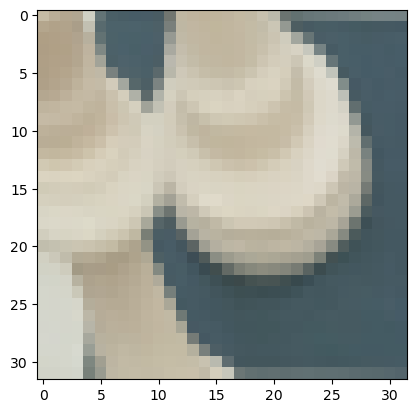

In [ ]:
x, y = ds[0]

x = x.unsqueeze(0)

sq_size = (x.shape[2]//10, x.shape[3]//10)
B = x.shape[0]
C = x.shape[1]
if C != 3:
    raise Exception("Invalid Image")

board_split = x.reshape(B, C, 10, sq_size[0], 10, sq_size[1]).permute(0,1,2,4,3,5)

plt.imshow(board_split[0,:,3,1,:,:].permute(1,2,0));

y['y'].argmax(dim=2), y['file_path'], y['y'].argmax(dim=2)[2,0]

In [ ]:
with torch.inference_mode():
    x = ds[0][0].unsqueeze(0).to(device)
    preds = model(x)
preds.shape

torch.Size([1, 8, 8, 13])

In [ ]:
board = preds.squeeze().argmax(2).rot90(1).unsqueeze(0)
print(board.shape)
cu.tensorToFEN_MAX(board)

torch.Size([1, 8, 8])


'r1bqkb1r/pp1n1ppp/4p3/2pp4/P7/2B3P1/1P1NP1BP/R1BQ1RK1'

In [ ]:
img = Image.open("../data/data_old/9.jpeg").convert("RGB").resize((640,640))
img = ds.transforms(img)

with torch.inference_mode():
    x = img.unsqueeze(0).to(device)
    preds = model(x)

board = preds.squeeze().argmax(2).rot90(1).unsqueeze(0)
cu.tensorToFEN_MAX(board)

'3r1r1r/pp2kQpp/2ppn3/1pP1n1P1/7P/3QP3/P4R2/RQ2R2R'